# 📊 Analyse exploratoire — Stock et ventes sur produits frais

**Objectif** : comprendre les dynamiques de stock, de demande et de pertes sur des
références à courte durée de vie (DLC), afin d'identifier les SKU à risque et de
préparer la phase de modélisation prédictive.

**Données** : jeu de données simulé représentant 8 références (yaourts à boire,
fromages frais, desserts lactés) sur une année complète, avec saisonnalité
(Ramadan, été, fêtes) et incidents logistiques aléatoires.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Chargement des données

In [2]:
df = pd.read_csv('../data/stock_ventes_simules.csv', parse_dates=['date'])
produits = pd.read_csv('../data/referentiel_produits.csv')

print(f"Période : {df['date'].min().date()} -> {df['date'].max().date()}")
print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de SKU : {df['sku'].nunique()}")
df.head()


Période : 2025-01-01 -> 2025-12-30
Nombre de lignes : 2,912
Nombre de SKU : 8


,date,sku,produit,famille,dlc_jours,demande,production,stock_fin_journee,stock_securite,perte_dlc,rupture
0,2025-01-01,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,737,701,2231,612,176,False
1,2025-01-02,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,883,919,2197,612,70,False
2,2025-01-03,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,791,757,2163,612,0,False
3,2025-01-04,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,558,572,2177,612,0,False
4,2025-01-05,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,654,620,2143,612,0,False


In [3]:
produits

,sku,nom,famille,dlc_jours,demande_base
0,YAB-001,Yaourt à boire nature 1L,Yaourt à boire,18,850
1,YAB-002,Yaourt à boire fraise 1L,Yaourt à boire,18,620
2,YAB-003,Yaourt à boire pêche 1L,Yaourt à boire,18,410
3,FRF-001,Fromage frais nature 500g,Fromage frais,21,530
4,FRF-002,Fromage frais ail & fines herbes,Fromage frais,21,280
5,DES-001,Crème dessert vanille pack x4,Dessert lacté,14,460
6,DES-002,Crème dessert chocolat pack x4,Dessert lacté,14,590
7,DES-003,Flan caramel pack x4,Dessert lacté,12,310


## 2. Vue d'ensemble : demande, production et stock

On commence par regarder l'évolution agrégée sur l'année, toutes références
confondues, pour repérer les grandes tendances et les pics saisonniers.

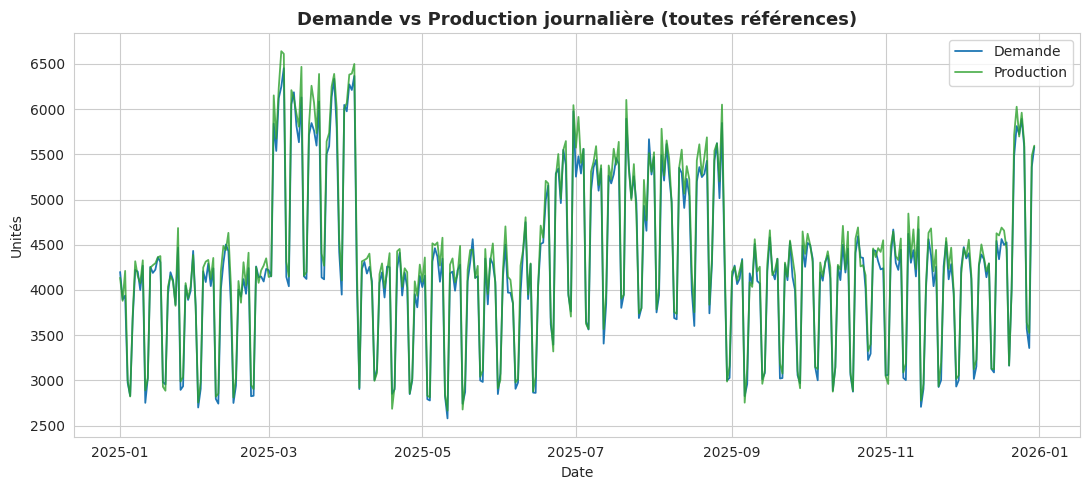

In [4]:
df_jour = df.groupby('date', as_index=False)[['demande', 'production', 'perte_dlc']].sum()

fig, ax = plt.subplots()
ax.plot(df_jour['date'], df_jour['demande'], label='Demande', color='#1f77b4', linewidth=1.3)
ax.plot(df_jour['date'], df_jour['production'], label='Production', color='#2ca02c', linewidth=1.3, alpha=0.8)
ax.set_title("Demande vs Production journalière (toutes références)")
ax.set_xlabel("Date")
ax.set_ylabel("Unités")
ax.legend()
plt.tight_layout()
plt.show()


On observe nettement trois pics de demande dans l'année : un pic important
autour de **mars-avril (Ramadan)**, un pic estival, et un pic plus court en fin
d'année (fêtes). Ces périodes sont critiques pour le dimensionnement du stock de
sécurité.

## 3. Analyse par famille de produits

In [5]:
df_famille = df.groupby('famille', as_index=False).agg(
    demande_totale=('demande', 'sum'),
    perte_dlc_totale=('perte_dlc', 'sum'),
    taux_rupture=('rupture', 'mean')
).sort_values('demande_totale', ascending=False)

df_famille['taux_rupture'] = (df_famille['taux_rupture'] * 100).round(2)
df_famille


,famille,demande_totale,perte_dlc_totale,taux_rupture
2,Yaourt à boire,722225,4842,6.68
0,Dessert lacté,516326,7311,0.37
1,Fromage frais,307221,4182,0.00


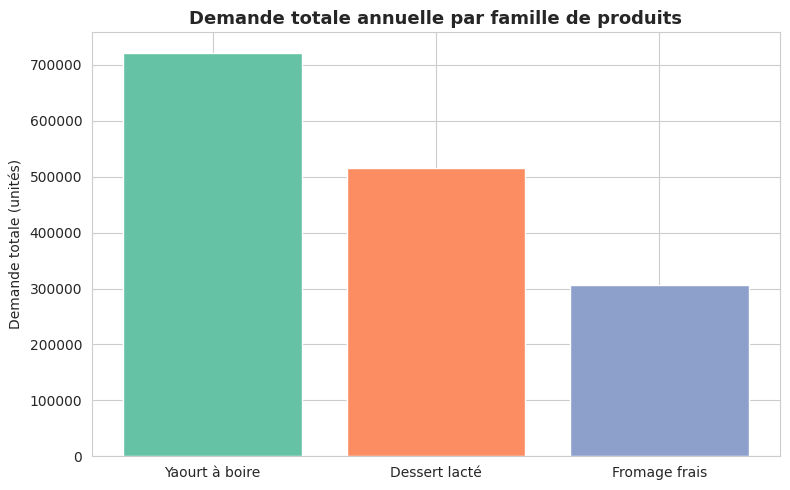

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('Set2', len(df_famille))
ax.bar(df_famille['famille'], df_famille['demande_totale'], color=colors)
ax.set_title("Demande totale annuelle par famille de produits")
ax.set_ylabel("Demande totale (unités)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 4. Pertes liées au dépassement de DLC

Les pertes DLC sont l'indicateur clé du sur-stockage sur produits frais. On
identifie ici les références les plus exposées.

In [7]:
df_sku = df.groupby(['sku', 'produit', 'famille', 'dlc_jours'], as_index=False).agg(
    demande_totale=('demande', 'sum'),
    perte_dlc_totale=('perte_dlc', 'sum'),
    taux_rupture=('rupture', 'mean')
)

df_sku['taux_perte_pct'] = (df_sku['perte_dlc_totale'] / df_sku['demande_totale'] * 100).round(2)
df_sku['taux_rupture_pct'] = (df_sku['taux_rupture'] * 100).round(2)
df_sku = df_sku.sort_values('taux_perte_pct', ascending=False)

df_sku[['sku', 'produit', 'dlc_jours', 'demande_totale', 'perte_dlc_totale', 'taux_perte_pct', 'taux_rupture_pct']]


,sku,produit,dlc_jours,demande_totale,perte_dlc_totale,taux_perte_pct,taux_rupture_pct
1,DES-002,Crème dessert chocolat pack x4,14,223934,3680,1.64,0.00
0,DES-001,Crème dessert vanille pack x4,14,174574,2529,1.45,0.00
3,FRF-001,Fromage frais nature 500g,21,201864,2782,1.38,0.00
4,FRF-002,Fromage frais ail & fines herbes,21,105357,1400,1.33,0.00
6,YAB-002,Yaourt à boire fraise 1L,18,235955,2487,1.05,3.30
2,DES-003,Flan caramel pack x4,12,117818,1102,0.94,1.10
7,YAB-003,Yaourt à boire pêche 1L,18,158515,955,0.60,10.16
5,YAB-001,Yaourt à boire nature 1L,18,327755,1400,0.43,6.59


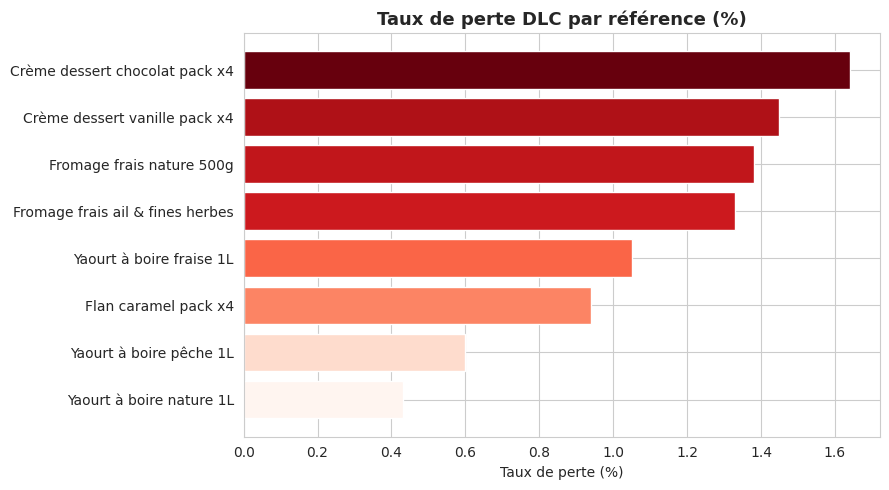

In [8]:
df_plot = df_sku.sort_values('taux_perte_pct')
fig, ax = plt.subplots(figsize=(9, 5))
norm = plt.Normalize(df_plot['taux_perte_pct'].min(), df_plot['taux_perte_pct'].max())
colors = plt.cm.Reds(norm(df_plot['taux_perte_pct']))
ax.barh(df_plot['produit'], df_plot['taux_perte_pct'], color=colors)
ax.set_title("Taux de perte DLC par référence (%)")
ax.set_xlabel("Taux de perte (%)")
plt.tight_layout()
plt.show()


**Lecture** : les références avec une DLC très courte (desserts lactés, 12-14
jours) sont structurellement plus exposées au risque de perte que les fromages
frais (DLC 21 jours) — ce qui confirme l'intuition métier et justifie un
traitement différencié du stock de sécurité par famille.

## 5. Classification ABC/XYZ des références

On croise ici deux dimensions :
- **A/B/C** : poids de la référence dans la demande totale (analyse Pareto)
- **X/Y/Z** : régularité de la demande (coefficient de variation)

Cette double lecture permet de prioriser les efforts de pilotage : les
références **AZ** (fort volume, forte variabilité) sont les plus critiques à
surveiller.

In [9]:
# Classification ABC (Pareto sur la demande)
df_sku = df_sku.sort_values('demande_totale', ascending=False).reset_index(drop=True)
df_sku['cum_pct'] = df_sku['demande_totale'].cumsum() / df_sku['demande_totale'].sum() * 100

def classe_abc(pct):
    if pct <= 70:
        return 'A'
    elif pct <= 90:
        return 'B'
    else:
        return 'C'

df_sku['classe_abc'] = df_sku['cum_pct'].apply(classe_abc)

# Classification XYZ (coefficient de variation de la demande journalière)
cv = df.groupby('sku')['demande'].agg(lambda x: x.std() / x.mean())
df_sku['cv_demande'] = df_sku['sku'].map(cv)

def classe_xyz(cv):
    if cv <= 0.25:
        return 'X'
    elif cv <= 0.45:
        return 'Y'
    else:
        return 'Z'

df_sku['classe_xyz'] = df_sku['cv_demande'].apply(classe_xyz)
df_sku['classe_abc_xyz'] = df_sku['classe_abc'] + df_sku['classe_xyz']

df_sku[['sku', 'produit', 'demande_totale', 'classe_abc', 'cv_demande', 'classe_xyz', 'classe_abc_xyz']]


,sku,produit,demande_totale,classe_abc,cv_demande,classe_xyz,classe_abc_xyz
0,YAB-001,Yaourt à boire nature 1L,327755,A,0.237357,X,AX
1,YAB-002,Yaourt à boire fraise 1L,235955,A,0.234253,X,AX
2,DES-002,Crème dessert chocolat pack x4,223934,A,0.238216,X,AX
3,FRF-001,Fromage frais nature 500g,201864,A,0.242399,X,AX
4,DES-001,Crème dessert vanille pack x4,174574,B,0.242485,X,BX
5,YAB-003,Yaourt à boire pêche 1L,158515,B,0.235964,X,BX
6,DES-003,Flan caramel pack x4,117818,C,0.235462,X,CX
7,FRF-002,Fromage frais ail & fines herbes,105357,C,0.241344,X,CX


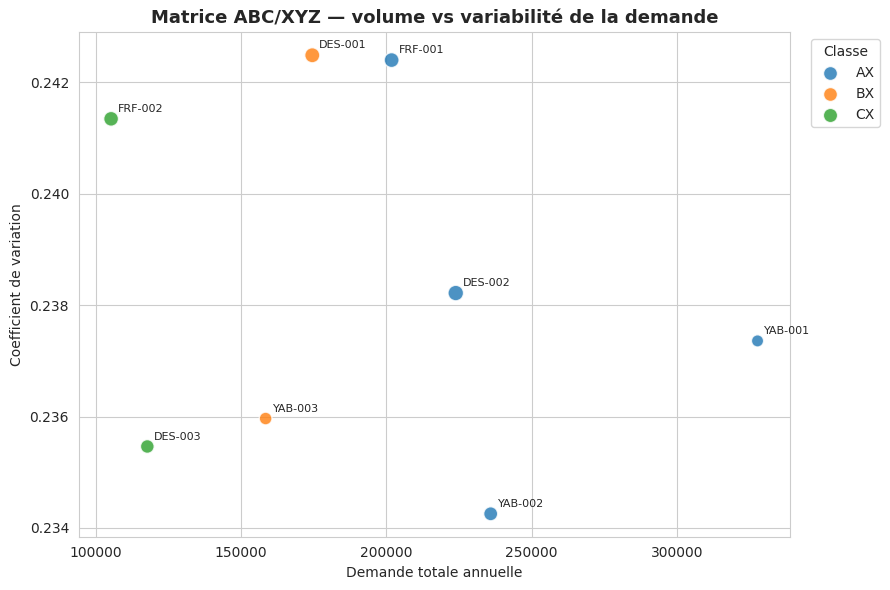

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
classes = df_sku['classe_abc_xyz'].unique()
palette = dict(zip(sorted(classes), sns.color_palette('tab10', len(classes))))

for classe, grp in df_sku.groupby('classe_abc_xyz'):
    ax.scatter(grp['demande_totale'], grp['cv_demande'],
               s=grp['taux_perte_pct']*40 + 60, label=classe,
               color=palette[classe], alpha=0.8, edgecolor='white')
    for _, row in grp.iterrows():
        ax.annotate(row['sku'], (row['demande_totale'], row['cv_demande']),
                    fontsize=8, xytext=(5, 5), textcoords='offset points')

ax.set_title("Matrice ABC/XYZ — volume vs variabilité de la demande")
ax.set_xlabel("Demande totale annuelle")
ax.set_ylabel("Coefficient de variation")
ax.legend(title='Classe', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Lecture** : les références classées **AZ ou AY** (volume élevé + variabilité
forte) sont prioritaires pour la mise en place d'un stock de sécurité dynamique
et d'une prévision de demande affinée — c'est précisément l'objectif du
notebook suivant.

## 6. Couverture de stock dans le temps

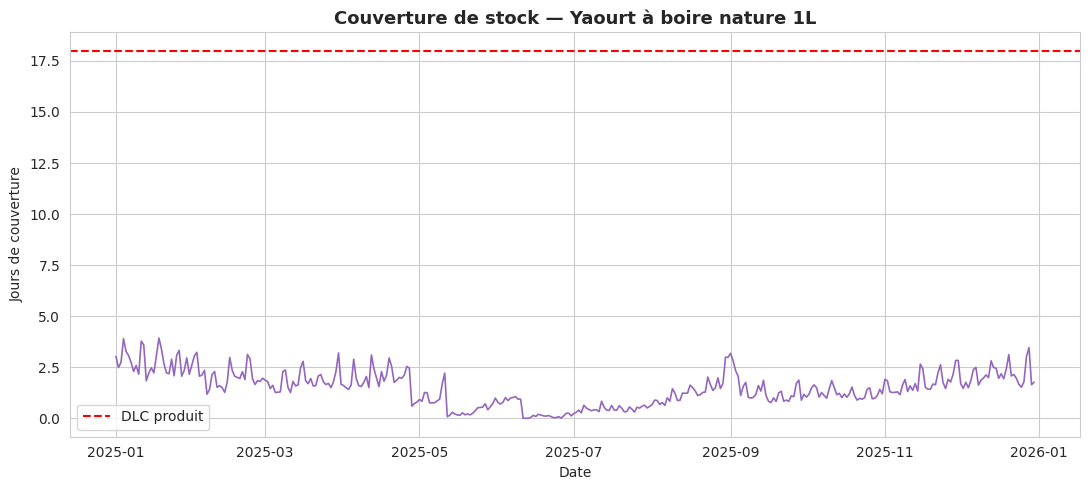

In [11]:
df['couverture_jours'] = (df['stock_fin_journee'] / df['demande'].replace(0, np.nan)).clip(upper=30)

sku_exemple = df_sku.iloc[0]['sku']
df_exemple = df[df['sku'] == sku_exemple].copy()

fig, ax = plt.subplots()
ax.plot(df_exemple['date'], df_exemple['couverture_jours'], color='#9467bd', linewidth=1.2)
ax.axhline(y=df_exemple['dlc_jours'].iloc[0], color='red', linestyle='--', label='DLC produit')
ax.set_title(f"Couverture de stock — {df_exemple['produit'].iloc[0]}")
ax.set_xlabel("Date")
ax.set_ylabel("Jours de couverture")
ax.legend()
plt.tight_layout()
plt.show()


Chaque dépassement de la ligne rouge (DLC) signale un risque de perte
imminent — c'est exactement ce type de signal que le score d'alerte développé
dans le notebook de détection d'anomalies devra capter automatiquement.

## 7. Synthèse de l'analyse exploratoire

**Constats principaux :**

1. La demande présente une saisonnalité marquée (Ramadan, été, fêtes) qu'un
   modèle de prévision devra impérativement intégrer
2. Les desserts lactés (DLC la plus courte) concentrent la majorité des pertes
3. La classification ABC/XYZ met en évidence 2 à 3 références prioritaires à
   forte variabilité et fort volume — cibles naturelles du futur modèle prédictif
4. Le taux de rupture global reste maîtrisé (~2-3%) mais certaines références
   présentent des pics de rupture corrélés aux périodes de forte demande

**Prochaine étape** : construction d'un modèle de prévision de la demande à
court terme (notebook `02_demand_forecasting_prophet.ipynb`) pour anticiper ces
pics et ajuster dynamiquement les niveaux de stock de sécurité.